# Overview


This notebook is an Exploratory Data Analysis (EDA) for Bitcoin (BTC), combining on-chain metrics from CoinMetrics with prediction market data from Polymarket. The goal appears to be understanding what drives BTC price and whether prediction market sentiment is a useful signal


# Data Sources

CoinMetrics: Comprehensive on‑chain dataset providing Bitcoin price history, supply
information, transaction activity, network usage, hash rate, and other fundamental blockchain
metrics.​

Polymarket Prediction Data: Prediction market data capturing crowd-sourced sentiment (buy/sell prices, order sizes, odds).

Alternative.me: Crypto Fear & Greed Index Data: market‑sentiment indicator scaled from 0 (extreme fear) to
100 (extreme greed), based specifically on Bitcoin‑related signals such as volatility,
momentum, social media sentiment and market dominance.

SP500: SP500 data from googlefinance

# Data Retrieval

- Polymarket data provided by Trilemma Foundation. https://drive.google.com/drive/folders/1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif
- Crypto Fear & Greed Index and SP500 have been saved to https://drive.google.com/drive/folders/1ZQDb23jt6Yh3Tma-eAIkIXMxWXeJhwpX?usp=drive_link

# Analysis methodologies

## Methodology 1:

We first perform statistical analysis on 
1. BTC data
2. Polymarket data. We first collect all the trades in Polymarket data which are related to bitcoin/crypto. We then look for trades which have a positive outcome based on token data. We try to correlate these trades with the odds history. 
3. BTC and Polymarket data is next combined. We perform statistical analysis to find some correlation/autocorrelation between PriceUSD in BTC with combined polymarket data generated from step 2.
4. Determine regime change in BTC data and see if it is correlated to SP500.

### Statistical analysis   
ACF/PACF Analysis — Autocorrelation and partial autocorrelation plots to understand serial dependence in time series.

Stationarity Testing — Augmented Dickey-Fuller (ADF) tests with helper functions to classify series as stationary or non-stationary.

Feature Engineering — Derived features including MVRV z-score, MVRV gradient, MVRV acceleration, MVRV zone, MVRV volatility, price vs. moving average, 
price MA, signal confidence, and Polymarket sentiment score.

Correlation Analysis — Computed correlations of all features against PriceUSD

## Methodology 2:

In a Bitcoin accumulation model, market psychology is just as critical as raw price action. By quantifying human emotion, the FGI acts as a powerful **contrarian indicator**:
In this section, we will load the historical FGI dataset from our local `data/` folder, merge it with our Bitcoin price history, and rigorously backtest its relationship against future price momentum. Our goal is to determine if these sentiment extremes can serve as reliable algorithmic triggers to optimize when we buy and when we sell.

# Summary of analysis.

- When 100 day MA is above 200 day MA, the PriceUSD of BTC is increasing.

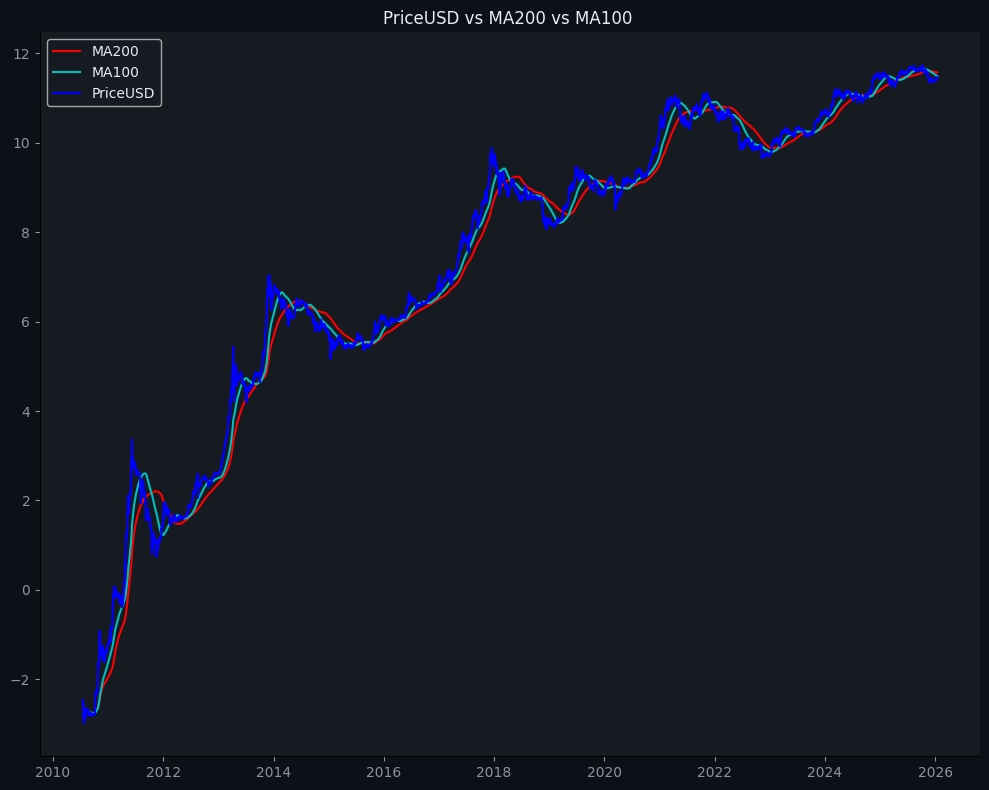

- There is a trend and a seasonal variation in PriceUSD with time. The period of seasonal fluctuation is 2 years.

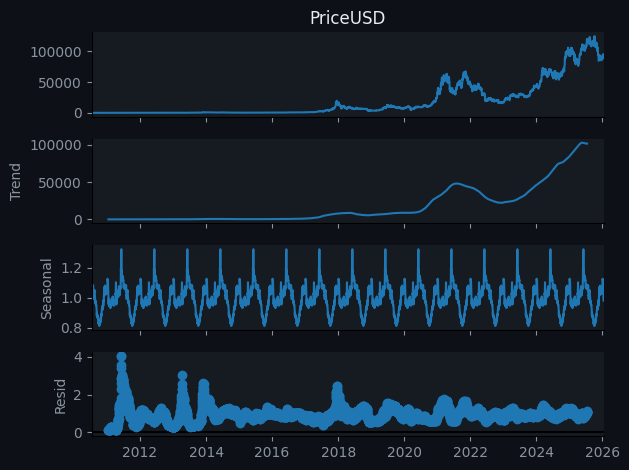

- There is a very low autocorrelation of PriceUSD with previous time periods.

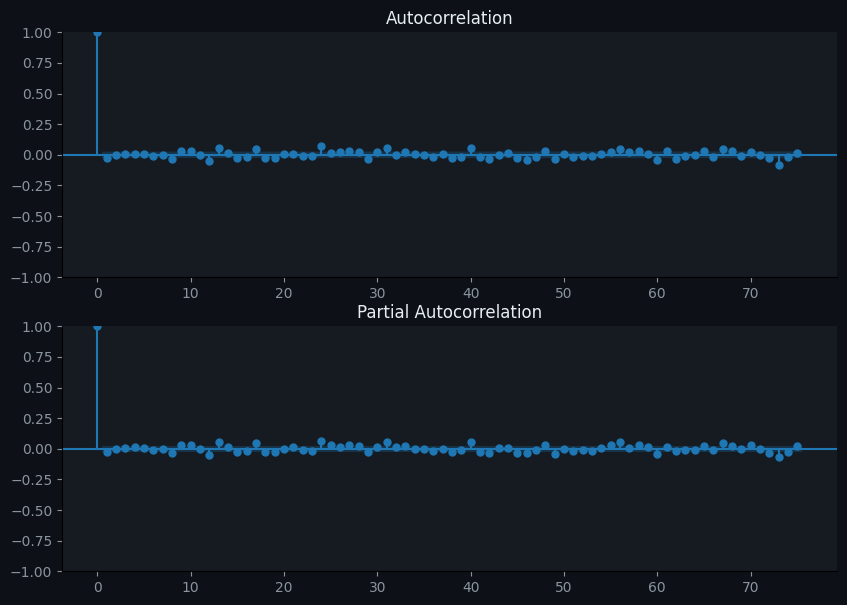

- Best fit for Distribution of PriceUSD returns is Cauchy/LogNormal.

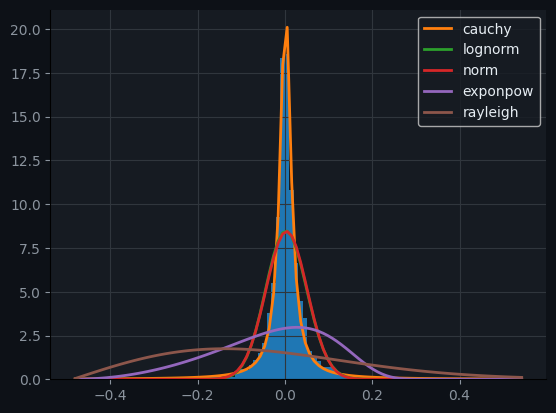

- Correlations does not seem to be constant. they seem to be changing across time periods. 

Below is a plot of correlation of PriceUSD with HashRate.

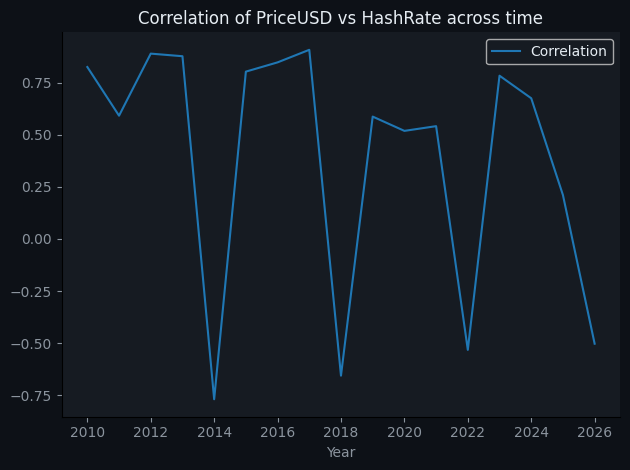

- For 2025, PriceUSD seems to have some regime changes. These points seem to be correlated to market events.

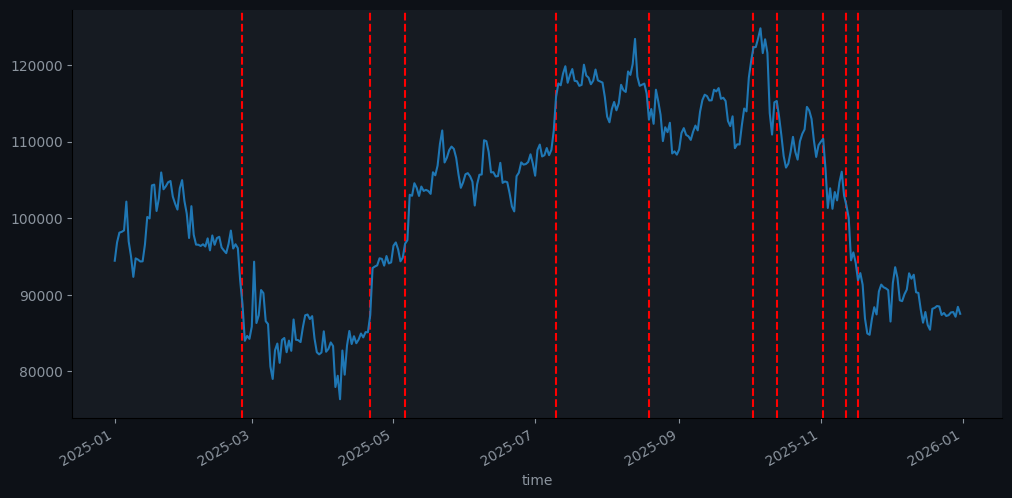

<table>
  <caption><b>Market events for regime change dates</b></caption>
  <thead>
    <tr>
      <th>Date</th>
      <th>Event</th>
      <th>Link</th>  
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>25-02-2025</td>
      <td>Nasdaq falls for 4th straight day.</td>
      <td>https://www.investopedia.com/dow-jones-today-02252025-11685876</td>  
    </tr>
    <tr>
      <td>2025-04-21</td>
      <td>Stocks Fall Sharply as Trump Ramps Up Criticism of Fed Chair Powell; Dollar Slides to 3-Year Low, Gold Jumps to New High</td>
        <td>https://www.investopedia.com/dow-jones-today-04212025-11718673</td>
    </tr>
    <tr>
      <td>2025-07-10</td>
      <td>Nasdaq Hit New Highs as Airline Stocks Soar After Strong Delta Earnings; Bitcoin Surges to Record</td>
        <td>https://www.investopedia.com/dow-jones-today-07102025-11769518</td>
    </tr>
    <tr>
      <td>2025-08-19</td>
      <td>Nasdaq Fall as Tech Stocks Tumble,Dow Closes Little Changed After Touching All-Time High</td>
        <td>https://www.investopedia.com/dow-jones-today-08192025-11793339</td>
    </tr>
   <tr>
      <td>2025-10-13</td>
      <td>Stocks Close Sharply Higher as Trump Softens Tone on China; Chip Shares Soar on Broadcom Deal With OpenAI</td>
        <td>https://www.investopedia.com/dow-jones-today-10132025-11828817</td>
    </tr>
    <tr>
      <td>2025-11-12</td>
      <td>Dow Closes Above 48000 for the First Time Ahead of House Vote to End US Government Shutdown; Nasdaq Slips</td>
        <td>https://www.investopedia.com/dow-jones-today-11122025-11847653</td>
    </tr>
    <tr>
      <td>2025-11-17</td>
      <td>Stock Indexes Close Down Sharply Ahead of Nvidia, Retail Results; Dow Sheds 550 Points; Google Parent Hits Record High</td>
        <td>https://www.investopedia.com/dow-jones-today-11172025-11850528</td>
    </tr>
      
  </tbody>
</table>


- So it is probable, PriceUSD has some correlation with SP500. The correlation value is 0.425





  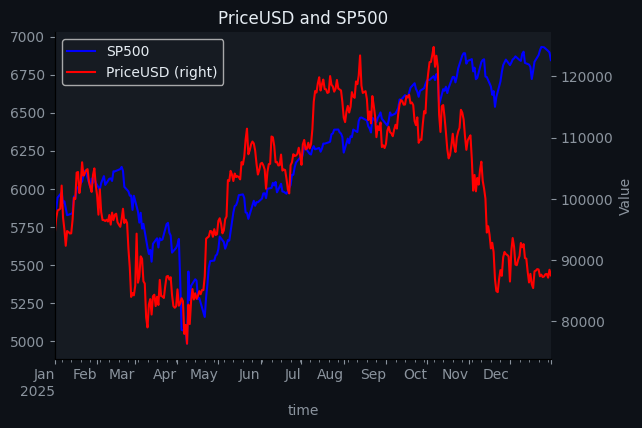

- Based on Polymarkets data there is a correlation between Odds (Price based on OrderBook) and Trades price. Granger causality also shows Price (Odds) to be a causing Trades Price.

- Price (Odds) seems to be a factor influencing PriceUSD. There is a corelation between PriceUSD and Odds data.

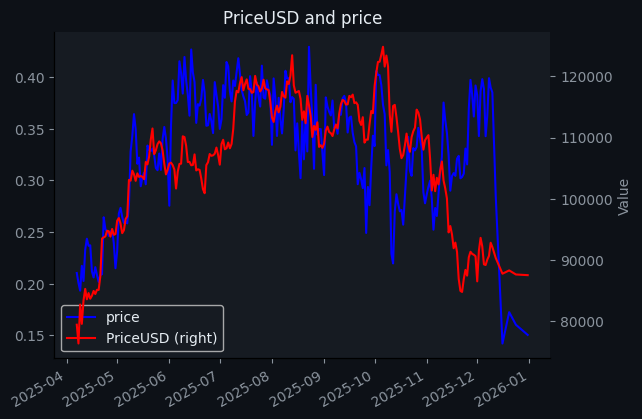

- Analysis of correlations between BTC Price data and the various polymarket features.

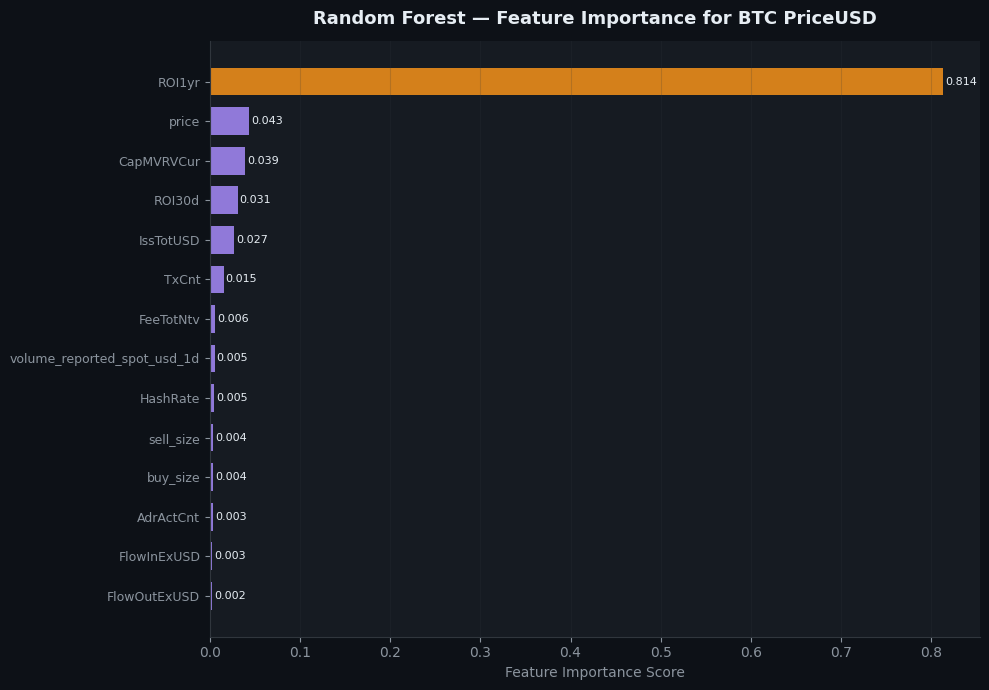

- FGI shows a moderate positive correlation with Bitcoin PriceUSD (Pearson: 0.4237). 
While greed generally rises with price, the bounded 0-100 sentiment oscillator does not perfectly track Bitcoin's unbounded, long-term exponential growt
  <br>
  Knowing that the market was greedy while prices were high doesn't tell our algorithm what to do next. For next analysis phase abandon backward-looking correlations evaluate forward returns (30, 90,and 180 days) for each sentiment group.



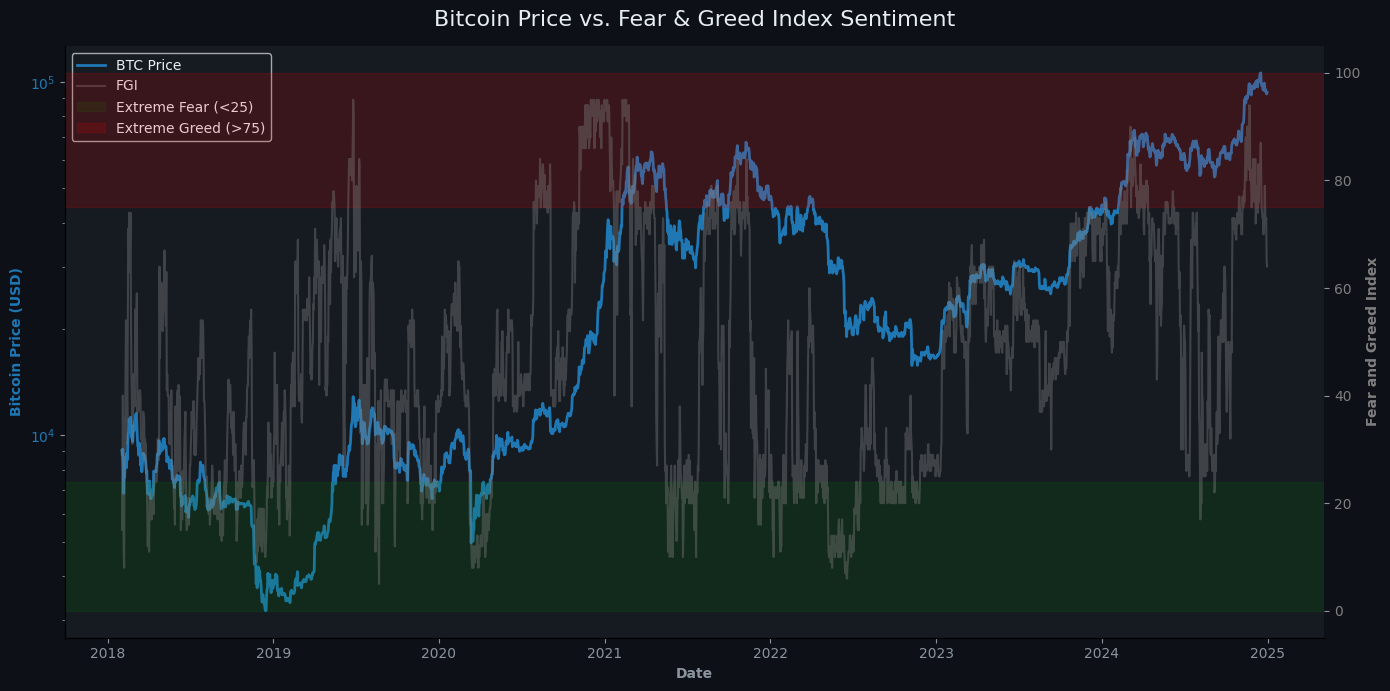

- Forward Returns by Sentiment: 30 to 180 day Forward returns. The 30-day forward return exhibits a positive relationship with sentiment. When the market enters "Greed," the trend tends to persist over the next month. Extreme euphoria rarely collapses instantly; it sustains itself, meaning a naive contrarian strategy (shorting the moment the market turns greedy) would result in missing significant upside momentum

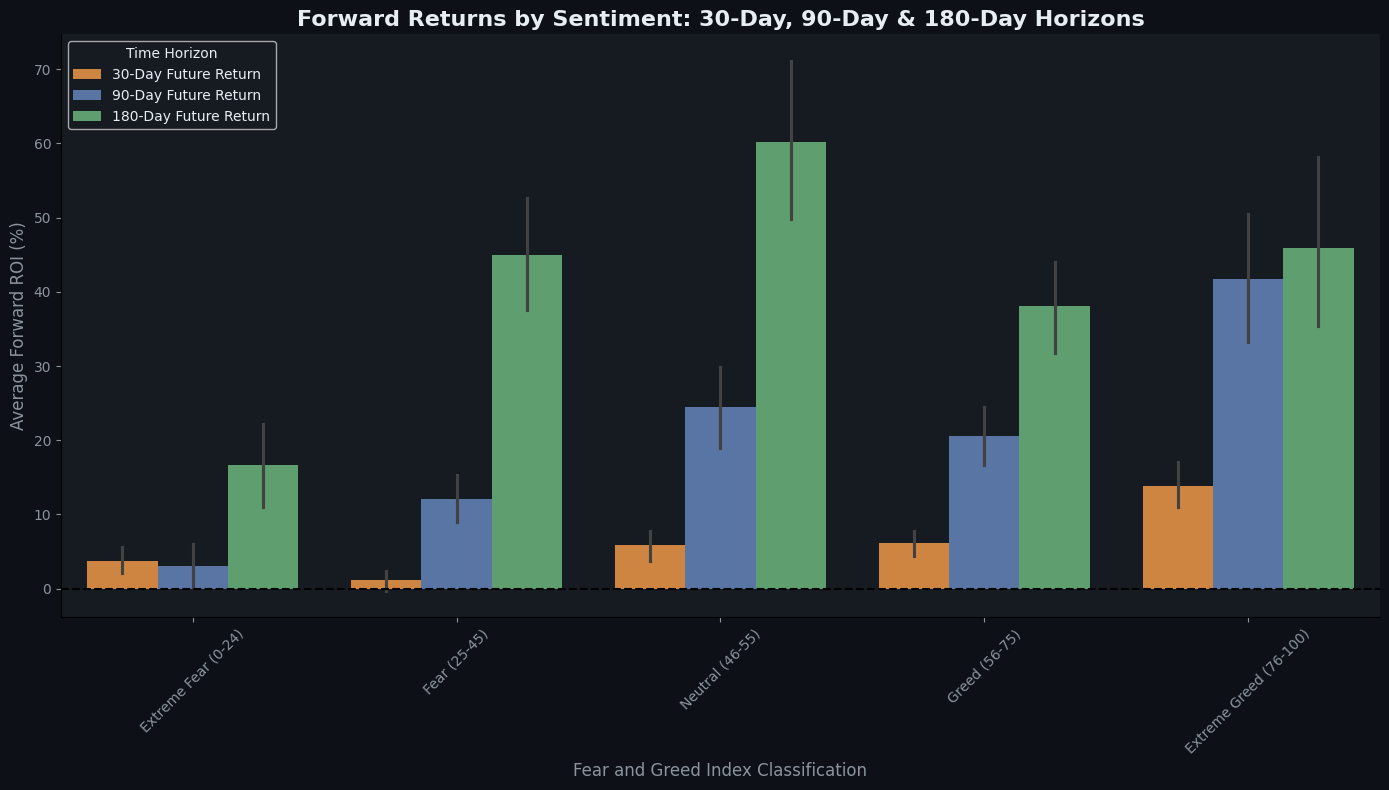

# Prediction Market Exploration

Our statistical analysis reveals that BTC/USD Price exhibits very low autocorrelation with previous time periods, suggesting that past price action is a limited predictor of immediate future performance. Furthermore, correlations between various attributes are highly dynamic, frequently shifting in both strength and direction over time. 

Key Correlation Insights
Order Book & Odds Data: There is a discernible correlation between BTC price and time-series odds reconstructed from order book data. These "implied probabilities" from platforms like Polymarket serve as a real-time reflection of market sentiment.

Equity Markets: BTC continues to show a significant relationship with broader macro-assets. Its correlation with the S&P 500 is approximately 0.42.

Sentiment Indicators: We found a strong positive correlation between BTC price and the Crypto Fear and Greed Index (FGI). In the short term (30-day), momentum is the primary driver. Historically, periods of "Extreme Greed" (index levels 76–100) have yielded the highest immediate returns.

Proposed Strategy Integration
<br>
We recommend applying the FGI sentiment index as a primary alpha signal. This should be utilized alongside:
Fundamental On-Chain Metrics: MVRV (Market Value to Realized Value) and the 200-day Moving Average (MA).
<br>
Predictive Market Data: Incorporating Polymarket trade performance and implied volatility from order book "odds" to anticipate local bottoms and momentum shifts.